C:\Users\fishb\AppData\Local\Temp\ipykernel_18684\2615012675.py:120: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


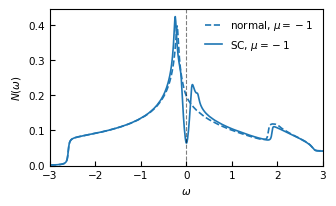

In [10]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np


# -------------------------- paths --------------------------
data_dir = Path(".").resolve()
os.chdir(data_dir)

style_path = data_dir / "publication.mplstyle"
if style_path.exists():
    plt.style.use(style_path)


def dos_filename(data_dir, state, U, mu, J, nk_dos, gamma):
    """Load files saved as {state}_dos_U=..._mu=..._J=..._nkdos=..._gamma=....npy."""
    tag = f"U={U}_mu={mu}_J={J}_nkdos={nk_dos}_gamma={gamma}"
    return data_dir / f"{state}_dos_{tag}.npy"


def load_dos_pair(data_dir, U, mu, J, nk_dos, gamma):
    normal_path = dos_filename(data_dir, "normal", U, mu, J, nk_dos, gamma)
    sc_path = dos_filename(data_dir, "sc", U, mu, J, nk_dos, gamma)

    normal_dos = np.load(normal_path)
    sc_dos = np.load(sc_path)

    if normal_dos.shape != sc_dos.shape:
        raise ValueError(
            f"Shape mismatch for mu={mu}: "
            f"normal_dos.shape={normal_dos.shape}, sc_dos.shape={sc_dos.shape}"
        )

    return normal_dos, sc_dos


# -------------------------- user parameters --------------------------
U = 2
J = 0.8
nk_dos = 256
gamma = 0.02

# mu_values = [-1.0, -1.2, -1.4]
mu_values = [-1.0]

# These must match the DOS-generation script.
omega_min = -3.0
omega_max = 3.0

xlim = (-3.0, 3.0)
ylim = None


# -------------------------- load data --------------------------
normal_dos_list = []
sc_dos_list = []

for mu in mu_values:
    normal_dos, sc_dos = load_dos_pair(
        data_dir=data_dir,
        U=U,
        mu=mu,
        J=J,
        nk_dos=nk_dos,
        gamma=gamma,
    )
    normal_dos_list.append(normal_dos)
    sc_dos_list.append(sc_dos)

numomega = normal_dos_list[0].shape[0]
omegas = np.linspace(omega_min, omega_max, numomega)


# -------------------------- plot --------------------------
fig, ax = plt.subplots()

colors = ["C0", "C1", "C2", "C3", "C4", "C5"]

for i, mu in enumerate(mu_values):
    color = colors[i % len(colors)]
    normal_dos = normal_dos_list[i]
    sc_dos = sc_dos_list[i]

    ax.plot(
        omegas,
        normal_dos,
        "--",
        color=color,
        linewidth=1.2,
        label=rf"normal, $\mu={mu:g}$",
    )

    ax.plot(
        omegas,
        sc_dos,
        "-",
        color=color,
        linewidth=1.2,
        label=rf"SC, $\mu={mu:g}$",
    )

ax.axvline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"$N(\omega)$")

if xlim is not None:
    ax.set_xlim(*xlim)

if ylim is not None:
    ax.set_ylim(*ylim)
else:
    ax.set_ylim(bottom=0.0)

ax.legend(loc="best", handlelength=1.6, numpoints=1, frameon=False)
ax.tick_params(direction="in")

fig.tight_layout()

# plt.savefig("fermi_arc_normal_sc_dos.pdf", bbox_inches="tight")
# plt.savefig("fermi_arc_normal_sc_dos.png", dpi=600, bbox_inches="tight")
# plt.close()
plt.show()


C:\Users\fishb\AppData\Local\Temp\ipykernel_18684\2704456347.py:120: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


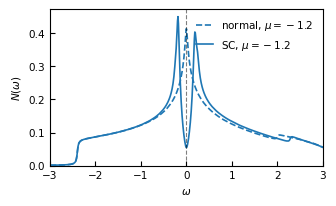

In [5]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np


# -------------------------- paths --------------------------
data_dir = Path(".").resolve()
os.chdir(data_dir)

style_path = data_dir / "publication.mplstyle"
if style_path.exists():
    plt.style.use(style_path)


def dos_filename(data_dir, state, U, mu, J, nk_dos, gamma):
    """Load files saved as {state}_dos_U=..._mu=..._J=..._nkdos=..._gamma=....npy."""
    tag = f"U={U}_mu={mu}_J={J}_nkdos={nk_dos}_gamma={gamma}"
    return data_dir / f"{state}_dos_{tag}.npy"


def load_dos_pair(data_dir, U, mu, J, nk_dos, gamma):
    normal_path = dos_filename(data_dir, "normal", U, mu, J, nk_dos, gamma)
    sc_path = dos_filename(data_dir, "sc", U, mu, J, nk_dos, gamma)

    normal_dos = np.load(normal_path)
    sc_dos = np.load(sc_path)

    if normal_dos.shape != sc_dos.shape:
        raise ValueError(
            f"Shape mismatch for mu={mu}: "
            f"normal_dos.shape={normal_dos.shape}, sc_dos.shape={sc_dos.shape}"
        )

    return normal_dos, sc_dos


# -------------------------- user parameters --------------------------
U = 2
J = 0.8
nk_dos = 256
gamma = 0.02

# mu_values = [-1.0, -1.2, -1.4]
mu_values = [-1.2]

# These must match the DOS-generation script.
omega_min = -3.0
omega_max = 3.0

xlim = (-3.0, 3.0)
ylim = None


# -------------------------- load data --------------------------
normal_dos_list = []
sc_dos_list = []

for mu in mu_values:
    normal_dos, sc_dos = load_dos_pair(
        data_dir=data_dir,
        U=U,
        mu=mu,
        J=J,
        nk_dos=nk_dos,
        gamma=gamma,
    )
    normal_dos_list.append(normal_dos)
    sc_dos_list.append(sc_dos)

numomega = normal_dos_list[0].shape[0]
omegas = np.linspace(omega_min, omega_max, numomega)


# -------------------------- plot --------------------------
fig, ax = plt.subplots()

colors = ["C0", "C1", "C2", "C3", "C4", "C5"]

for i, mu in enumerate(mu_values):
    color = colors[i % len(colors)]
    normal_dos = normal_dos_list[i]
    sc_dos = sc_dos_list[i]

    ax.plot(
        omegas,
        normal_dos,
        "--",
        color=color,
        linewidth=1.2,
        label=rf"normal, $\mu={mu:g}$",
    )

    ax.plot(
        omegas,
        sc_dos,
        "-",
        color=color,
        linewidth=1.2,
        label=rf"SC, $\mu={mu:g}$",
    )

ax.axvline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"$N(\omega)$")

if xlim is not None:
    ax.set_xlim(*xlim)

if ylim is not None:
    ax.set_ylim(*ylim)
else:
    ax.set_ylim(bottom=0.0)

ax.legend(loc="best", handlelength=1.6, numpoints=1, frameon=False)
ax.tick_params(direction="in")

fig.tight_layout()

# plt.savefig("fermi_arc_normal_sc_dos.pdf", bbox_inches="tight")
# plt.savefig("fermi_arc_normal_sc_dos.png", dpi=600, bbox_inches="tight")
# plt.close()
plt.show()


C:\Users\fishb\AppData\Local\Temp\ipykernel_18684\2201328568.py:120: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


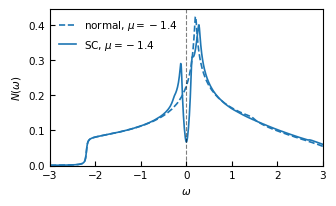

In [7]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np


# -------------------------- paths --------------------------
data_dir = Path(".").resolve()
os.chdir(data_dir)

style_path = data_dir / "publication.mplstyle"
if style_path.exists():
    plt.style.use(style_path)


def dos_filename(data_dir, state, U, mu, J, nk_dos, gamma):
    """Load files saved as {state}_dos_U=..._mu=..._J=..._nkdos=..._gamma=....npy."""
    tag = f"U={U}_mu={mu}_J={J}_nkdos={nk_dos}_gamma={gamma}"
    return data_dir / f"{state}_dos_{tag}.npy"


def load_dos_pair(data_dir, U, mu, J, nk_dos, gamma):
    normal_path = dos_filename(data_dir, "normal", U, mu, J, nk_dos, gamma)
    sc_path = dos_filename(data_dir, "sc", U, mu, J, nk_dos, gamma)

    normal_dos = np.load(normal_path)
    sc_dos = np.load(sc_path)

    if normal_dos.shape != sc_dos.shape:
        raise ValueError(
            f"Shape mismatch for mu={mu}: "
            f"normal_dos.shape={normal_dos.shape}, sc_dos.shape={sc_dos.shape}"
        )

    return normal_dos, sc_dos


# -------------------------- user parameters --------------------------
U = 2
J = 0.8
nk_dos = 256
gamma = 0.02

# mu_values = [-1.0, -1.2, -1.4]
mu_values = [-1.4]

# These must match the DOS-generation script.
omega_min = -3.0
omega_max = 3.0

xlim = (-3.0, 3.0)
ylim = None


# -------------------------- load data --------------------------
normal_dos_list = []
sc_dos_list = []

for mu in mu_values:
    normal_dos, sc_dos = load_dos_pair(
        data_dir=data_dir,
        U=U,
        mu=mu,
        J=J,
        nk_dos=nk_dos,
        gamma=gamma,
    )
    normal_dos_list.append(normal_dos)
    sc_dos_list.append(sc_dos)

numomega = normal_dos_list[0].shape[0]
omegas = np.linspace(omega_min, omega_max, numomega)


# -------------------------- plot --------------------------
fig, ax = plt.subplots()

colors = ["C0", "C1", "C2", "C3", "C4", "C5"]

for i, mu in enumerate(mu_values):
    color = colors[i % len(colors)]
    normal_dos = normal_dos_list[i]
    sc_dos = sc_dos_list[i]

    ax.plot(
        omegas,
        normal_dos,
        "--",
        color=color,
        linewidth=1.2,
        label=rf"normal, $\mu={mu:g}$",
    )

    ax.plot(
        omegas,
        sc_dos,
        "-",
        color=color,
        linewidth=1.2,
        label=rf"SC, $\mu={mu:g}$",
    )

ax.axvline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"$N(\omega)$")

if xlim is not None:
    ax.set_xlim(*xlim)

if ylim is not None:
    ax.set_ylim(*ylim)
else:
    ax.set_ylim(bottom=0.0)

ax.legend(loc="best", handlelength=1.6, numpoints=1, frameon=False)
ax.tick_params(direction="in")

fig.tight_layout()

# plt.savefig("fermi_arc_normal_sc_dos.pdf", bbox_inches="tight")
# plt.savefig("fermi_arc_normal_sc_dos.png", dpi=600, bbox_inches="tight")
# plt.close()
plt.show()


C:\Users\fishb\AppData\Local\Temp\ipykernel_18684\4126060159.py:120: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


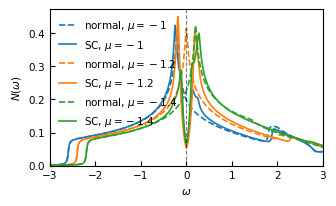

In [8]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np


# -------------------------- paths --------------------------
data_dir = Path(".").resolve()
os.chdir(data_dir)

style_path = data_dir / "publication.mplstyle"
if style_path.exists():
    plt.style.use(style_path)


def dos_filename(data_dir, state, U, mu, J, nk_dos, gamma):
    """Load files saved as {state}_dos_U=..._mu=..._J=..._nkdos=..._gamma=....npy."""
    tag = f"U={U}_mu={mu}_J={J}_nkdos={nk_dos}_gamma={gamma}"
    return data_dir / f"{state}_dos_{tag}.npy"


def load_dos_pair(data_dir, U, mu, J, nk_dos, gamma):
    normal_path = dos_filename(data_dir, "normal", U, mu, J, nk_dos, gamma)
    sc_path = dos_filename(data_dir, "sc", U, mu, J, nk_dos, gamma)

    normal_dos = np.load(normal_path)
    sc_dos = np.load(sc_path)

    if normal_dos.shape != sc_dos.shape:
        raise ValueError(
            f"Shape mismatch for mu={mu}: "
            f"normal_dos.shape={normal_dos.shape}, sc_dos.shape={sc_dos.shape}"
        )

    return normal_dos, sc_dos


# -------------------------- user parameters --------------------------
U = 2
J = 0.8
nk_dos = 256
gamma = 0.02

mu_values = [-1.0, -1.2, -1.4]
# mu_values = [-1.4]

# These must match the DOS-generation script.
omega_min = -3.0
omega_max = 3.0

xlim = (-3.0, 3.0)
ylim = None


# -------------------------- load data --------------------------
normal_dos_list = []
sc_dos_list = []

for mu in mu_values:
    normal_dos, sc_dos = load_dos_pair(
        data_dir=data_dir,
        U=U,
        mu=mu,
        J=J,
        nk_dos=nk_dos,
        gamma=gamma,
    )
    normal_dos_list.append(normal_dos)
    sc_dos_list.append(sc_dos)

numomega = normal_dos_list[0].shape[0]
omegas = np.linspace(omega_min, omega_max, numomega)


# -------------------------- plot --------------------------
fig, ax = plt.subplots()

colors = ["C0", "C1", "C2", "C3", "C4", "C5"]

for i, mu in enumerate(mu_values):
    color = colors[i % len(colors)]
    normal_dos = normal_dos_list[i]
    sc_dos = sc_dos_list[i]

    ax.plot(
        omegas,
        normal_dos,
        "--",
        color=color,
        linewidth=1.2,
        label=rf"normal, $\mu={mu:g}$",
    )

    ax.plot(
        omegas,
        sc_dos,
        "-",
        color=color,
        linewidth=1.2,
        label=rf"SC, $\mu={mu:g}$",
    )

ax.axvline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

ax.set_xlabel(r"$\omega$")
ax.set_ylabel(r"$N(\omega)$")

if xlim is not None:
    ax.set_xlim(*xlim)

if ylim is not None:
    ax.set_ylim(*ylim)
else:
    ax.set_ylim(bottom=0.0)

ax.legend(loc="best", handlelength=1.6, numpoints=1, frameon=False)
ax.tick_params(direction="in")

fig.tight_layout()

# plt.savefig("fermi_arc_normal_sc_dos.pdf", bbox_inches="tight")
# plt.savefig("fermi_arc_normal_sc_dos.png", dpi=600, bbox_inches="tight")
# plt.close()
plt.show()
